In [32]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
import cv2
%matplotlib inline

# PyTorch core
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# TorchVision
import torchvision.transforms.v2 as v2
from torchvision.models import inception_v3, resnet50, efficientnet_b4, EfficientNet_B4_Weights, ResNet50_Weights, Inception_V3_Weights, VGG19_BN_Weights, vgg19_bn
from torchvision.utils import make_grid

# Data utilities
from torch.utils.data.dataloader import DataLoader
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)


cuda


In [33]:
MAIN_PATH = r"C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Deep Learning\CNN\All Data About CNN\Face-Age-Gender Dataset\face_dataset"
TRAIN_PATH = os.path.join(MAIN_PATH,"train")
TEST_PATH = os.path.join(MAIN_PATH,"test")

IMG_SIZE = 224

EPOCHS = 10
BATCH_SIZE = 128
PATIENCE = 5

LR = 1e-5

MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

NUM_WORKERS = 0

In [34]:
class CustomDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = csv_file
        self.transform = transform
        
        # Encode labels
        unique_labels = sorted(self.data.iloc[:, 1].unique())
        self.label2idx = {label: idx for idx, label in enumerate(unique_labels)}
        # {'18-20': 0, '21-30': 1, '31-40': 2, '41-50': 3, '51-60': 4}

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        img_path = self.data.iloc[index, 0]
        label = self.data.iloc[index, 1]

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        return image, self.label2idx[label]

In [35]:
class FocalLoss(nn.Module):

    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super().__init__()

        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):

        ce_loss = F.cross_entropy(
            inputs,
            targets,
            reduction='none'
        )

        pt = torch.exp(-ce_loss)

        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()

        elif self.reduction == 'sum':
            return focal_loss.sum()

        else:
            return focal_loss

In [36]:
small_df = pd.read_csv(r"C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Deep Learning\CNN\All Data About CNN\Face Age Dataset\age_detection.csv")
train_df = pd.read_csv(os.path.join(MAIN_PATH,"train.csv"))
test_df = pd.read_csv(os.path.join(MAIN_PATH,"test.csv"))
small_df

,file,age,split
0,train/18-20/0.jpg,18-20,train
1,train/18-20/1.jpg,18-20,train
2,train/18-20/2.jpg,18-20,train
3,train/18-20/3.jpg,18-20,train
4,train/18-20/4.jpg,18-20,train
...,...,...,...
145,test/51-60/25.jpg,51-60,test
146,test/51-60/26.jpg,51-60,test
147,test/51-60/27.jpg,51-60,test
148,test/51-60/28.jpg,51-60,test


In [37]:
train_df

,id,full_path,gender,age
0,0,train/00000.jpg,1,66
1,1,train/00001.jpg,1,53
2,2,train/00002.jpg,1,20
3,3,train/00003.jpg,1,32
4,4,train/00004.jpg,1,21
...,...,...,...,...
34703,34703,train/34703.jpg,1,32
34704,34704,train/34704.jpg,1,28
34705,34705,train/34705.jpg,1,25
34706,34706,train/34706.jpg,1,19


In [38]:
test_df

,id,full_path
0,0,test/00000.jpg
1,1,test/00001.jpg
2,2,test/00002.jpg
3,3,test/00003.jpg
4,4,test/00004.jpg
...,...,...
8672,8672,test/08672.jpg
8673,8673,test/08673.jpg
8674,8674,test/08674.jpg
8675,8675,test/08675.jpg


In [39]:
train_df["age"].describe()

count    34708.000000
mean        37.346692
std         16.587891
min          1.000000
25%         25.000000
50%         32.000000
75%         48.000000
max        100.000000
Name: age, dtype: float64

{'whiskers': [<matplotlib.lines.Line2D at 0x21fd9534f50>,
 'caps': [<matplotlib.lines.Line2D at 0x21fd95351d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x21fd9534e10>],
 'medians': [<matplotlib.lines.Line2D at 0x21fd9535450>],
 'fliers': [<matplotlib.lines.Line2D at 0x21fd9535590>],
 'means': []}

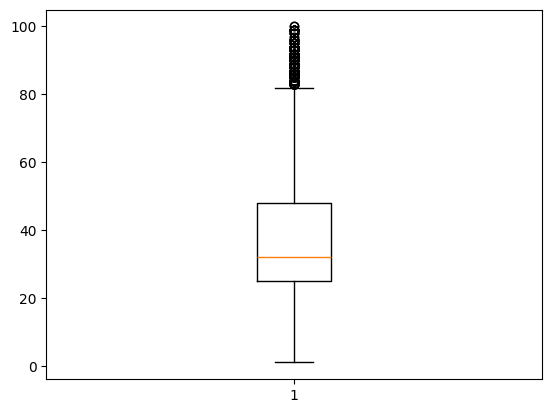

In [40]:
plt.boxplot(train_df['age'])

In [41]:
train_df = train_df[train_df['age'] <= 60][train_df['age'] >= 18]
train_df

C:\Users\ibrah.HIMA\AppData\Local\Temp\ipykernel_5800\4108938856.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  train_df = train_df[train_df['age'] <= 60][train_df['age'] >= 18]


,id,full_path,gender,age
1,1,train/00001.jpg,1,53
2,2,train/00002.jpg,1,20
3,3,train/00003.jpg,1,32
4,4,train/00004.jpg,1,21
5,5,train/00005.jpg,0,42
...,...,...,...,...
34703,34703,train/34703.jpg,1,32
34704,34704,train/34704.jpg,1,28
34705,34705,train/34705.jpg,1,25
34706,34706,train/34706.jpg,1,19


{'whiskers': [<matplotlib.lines.Line2D at 0x21fd823ccd0>,
 'caps': [<matplotlib.lines.Line2D at 0x21fd823c910>,
 'boxes': [<matplotlib.lines.Line2D at 0x21fd823ce10>],
 'medians': [<matplotlib.lines.Line2D at 0x21fd82a02d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x21fd82a0190>],
 'means': []}

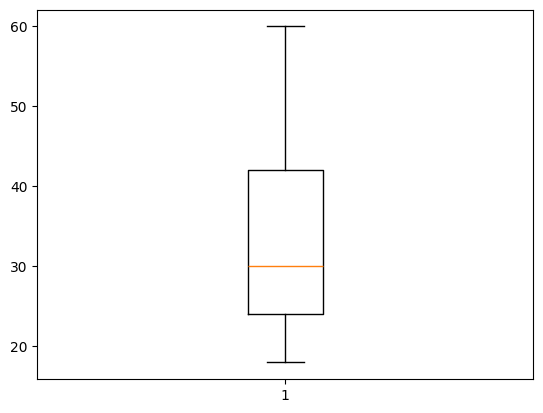

In [42]:
plt.boxplot(train_df['age'])

In [43]:
def set_age_range(x):
    if x in [x for x in range(18,21)]:
        return '18-20'
    elif x in [x for x in range(21,31)]:
        return '21-30'
    elif x in [x for x in range(31,41)]:
        return '31-40'
    elif x in [x for x in range(41,51)]:
        return '41-50'
    else:
        return '51-60'

In [44]:
train_df.rename(columns={'full_path': 'file'}, inplace=True)
train_df["age"] = train_df["age"].apply(lambda x: set_age_range(x))
train_df["file"] = train_df["file"].apply(lambda x: os.path.join(MAIN_PATH,x))
train_df.drop(['id','gender'],axis=1,inplace=True)
train_df.reset_index(drop=True,inplace=True)
train_df

,file,age
0,C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\D...,51-60
1,C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\D...,18-20
2,C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\D...,31-40
3,C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\D...,21-30
4,C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\D...,41-50
...,...,...
29660,C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\D...,31-40
29661,C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\D...,21-30
29662,C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\D...,21-30
29663,C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\D...,18-20


In [45]:
train_df['age'].value_counts()

age
21-30    12487
31-40     6645
41-50     4698
51-60     3484
18-20     2351
Name: count, dtype: int64

In [46]:
labels = set(train_df["age"].values)
labels

{'18-20', '21-30', '31-40', '41-50', '51-60'}

In [47]:
small_df["file"] = small_df["file"].apply(lambda x: os.path.join(r"C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Deep Learning\CNN\All Data About CNN\Face Age Dataset",x))
small_df.drop('split',axis=1,inplace=True)
small_df.reset_index(drop=True,inplace=True)
small_df

,file,age
0,C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\D...,18-20
1,C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\D...,18-20
2,C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\D...,18-20
3,C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\D...,18-20
4,C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\D...,18-20
...,...,...
145,C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\D...,51-60
146,C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\D...,51-60
147,C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\D...,51-60
148,C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\D...,51-60


In [48]:
small_df['age'].value_counts()

age
18-20    30
21-30    30
31-40    30
41-50    30
51-60    30
Name: count, dtype: int64

In [49]:
full_train_df = pd.concat([train_df,small_df],axis=0,)
full_train_df

,file,age
0,C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\D...,51-60
1,C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\D...,18-20
2,C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\D...,31-40
3,C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\D...,21-30
4,C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\D...,41-50
...,...,...
145,C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\D...,51-60
146,C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\D...,51-60
147,C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\D...,51-60
148,C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\D...,51-60


In [50]:
# train_df['age'] = train_df['age'].replace('18-20', '10-20')

In [51]:
train_df['age'].value_counts()

age
21-30    12487
31-40     6645
41-50     4698
51-60     3484
18-20     2351
Name: count, dtype: int64

3
(489, 489, 3)


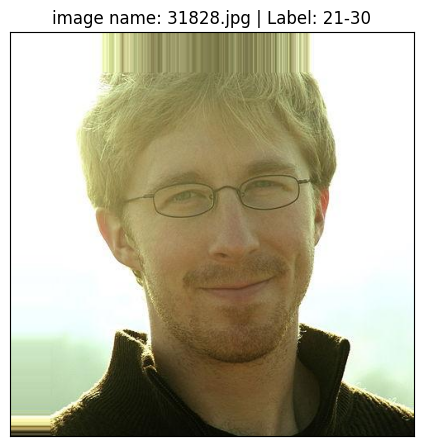

In [52]:
def show_img():
    img_path = np.random.choice(train_df["file"].values)
    img = plt.imread(os.path.join(MAIN_PATH,img_path))
    print(img.ndim)
    print(img.shape)
    if img.ndim == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        print(img.ndim)
    plt.imshow(img)
    plt.title(f"image name: {img_path.split('/')[-1]} | Label: {train_df[train_df['file']== img_path]['age'].values[0]}")
    plt.tight_layout()
    plt.yticks([])
    plt.xticks([])
    plt.show()

show_img()

In [53]:
def get_transforms(size=IMG_SIZE, apply_on_train=False):
    """
    Return a transform pipeline for the given split.

    Parameters
    ----------
    size           : int  — target image size (default 224)
    apply_on_train : bool — whether to include data augmentation
    """
    base = [
        v2.Resize((size, size)),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
    ]

    augmentation = [
        v2.RandomHorizontalFlip(),
        v2.RandomRotation(20),
        v2.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
        v2.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    ]

    tail = [
        v2.Normalize(MEAN, STD),
    ]

    if apply_on_train:
        return v2.Compose(base + augmentation + tail)
    return v2.Compose(base + tail)


In [54]:
train, temp_df = train_test_split(train_df, test_size=0.2, 
                                      random_state=42, stratify=train_df.iloc[:,1])
val, test   = train_test_split(temp_df, test_size=0.5, 
                                      random_state=42, stratify=temp_df.iloc[:,1])

print(f"Train Length is => {len(train)}")
print(f"val Length is => {len(val)}")
print(f"test Length is => {len(test)}")
print(f"Total = {len(train) + len(val) + len(test)}")

Train Length is => 23732
val Length is => 2966
test Length is => 2967
Total = 29665


In [55]:
train_ds = CustomDataset(train, get_transforms(IMG_SIZE, True))
val_ds   = CustomDataset(val, get_transforms(IMG_SIZE))
test_ds  = CustomDataset(test, get_transforms(IMG_SIZE))

In [56]:
train_ds.transform

Compose(
      Resize(size=[224, 224], interpolation=InterpolationMode.BILINEAR, antialias=True)
      ToImage()
      ToDtype(scale=True)
      RandomHorizontalFlip(p=0.5)
      RandomRotation(degrees=[-20.0, 20.0], interpolation=InterpolationMode.NEAREST, expand=False, fill=0)
      ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=(0.8, 1.2))
      RandomAffine(degrees=[0.0, 0.0], translate=(0.1, 0.1), interpolation=InterpolationMode.NEAREST, fill=0)
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)

In [57]:
val_ds.transform

Compose(
      Resize(size=[224, 224], interpolation=InterpolationMode.BILINEAR, antialias=True)
      ToImage()
      ToDtype(scale=True)
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)

In [58]:
test_ds.transform

Compose(
      Resize(size=[224, 224], interpolation=InterpolationMode.BILINEAR, antialias=True)
      ToImage()
      ToDtype(scale=True)
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)

In [59]:
train_dl = DataLoader(train_ds,BATCH_SIZE,True,num_workers=NUM_WORKERS,pin_memory=False)
val_dl = DataLoader(val_ds,BATCH_SIZE,False,num_workers=NUM_WORKERS,pin_memory=False)
test_dl = DataLoader(test_ds,BATCH_SIZE,False,num_workers=NUM_WORKERS,pin_memory=False)

In [60]:
def denorm(imgs):
    mean = torch.tensor(MEAN).view(1, 3, 1, 1)
    std = torch.tensor(STD).view(1, 3, 1, 1)
    return imgs * std + mean

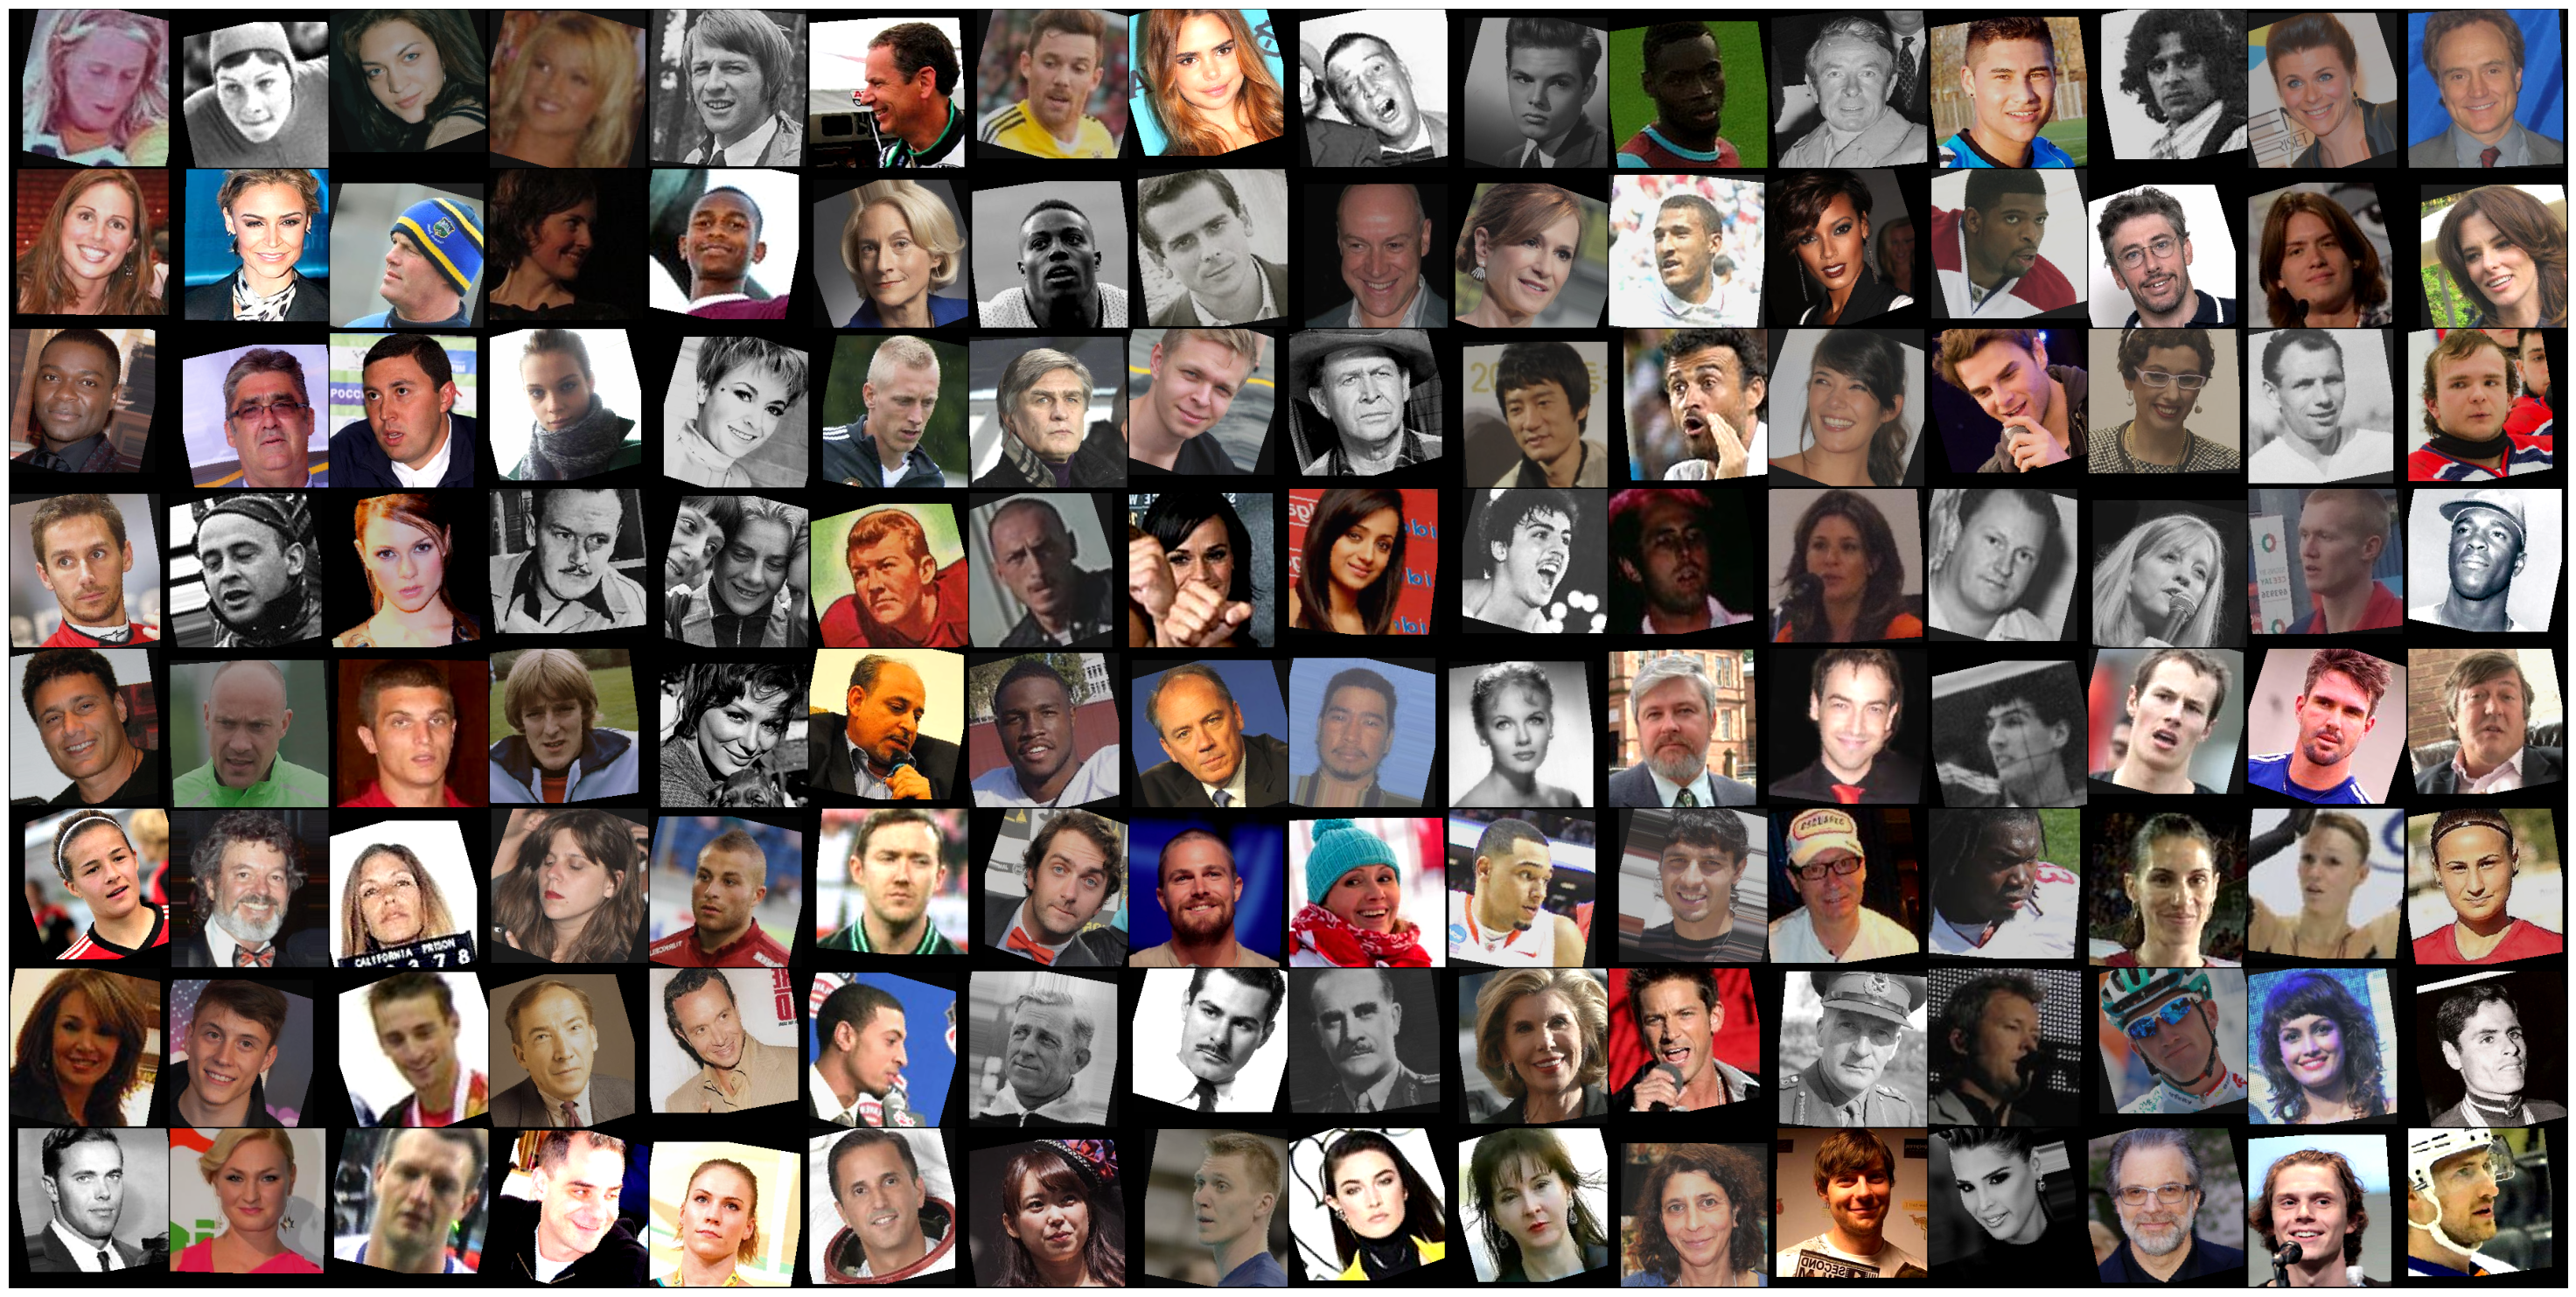

In [61]:
def show_grid_images(dataloader):
    imgs,labels = next(iter(dataloader))
    plt.figure(figsize=(30, 30))
    plt.imshow(make_grid(denorm(imgs),nrow=16).permute(1,2,0))
    plt.tight_layout()
    plt.axis('off')
    plt.show()

show_grid_images(train_dl)

In [ ]:
def replace_classifier(model, name):
    """
    Replace the final classification layer for any supported architecture.

    Supported: DenseNet, Inception, ResNet, VisionTransformer, SwinTransformer and VGG

    Parameters
    ----------
    model : pretrained PyTorch model
    name  : str — model class name used to identify architecture type

    Returns
    -------
    model with replaced classifier
    """
    if "DenseNet" in name:
        
        model.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(model.classifier.in_features, 5)
        )

    elif "Inception" in name:
        
        model.fc = nn.Sequential(
            nn.Dropout(p=0.3), 
            nn.Linear(model.fc.in_features, 5)
        )
        model.aux_logits = False
        model.AuxLogits  = None

    elif "ResNet" in name:
        model.fc = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(model.fc.in_features, 5)
        )

    elif "VisionTransformer" in name:
        model.heads = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(model.heads.head.in_features, 5)
        )

    elif "SwinTransformer" in name:
        model.head = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(model.head.in_features, 5)
        )
    else:
        model.classifier[6] = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(model.classifier[6].in_features, 5)
        )

    return model

In [ ]:
Model = resnet50(weights=ResNet50_Weights.DEFAULT)
Model = replace_classifier(Model,Model.__class__.__name__)
Model = Model.to(device)
optimizer = torch.optim.AdamW(Model.parameters(), lr=LR)
criterion = FocalLoss()

In [ ]:
def fit(model):
    history = []
    best_loss = float('inf')
    counter = 0
    for epoch in range(EPOCHS):

        train_all_loss=[]

        model.train()

        for batch in tqdm(train_dl,f"Epoch: {epoch+1}/{EPOCHS}"):
            imgs,labels = batch
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)

            loss = criterion(outputs,labels).to(device)

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            train_all_loss.append(loss.detach().cpu().item())

        train_loss = sum(train_all_loss) / len(train_all_loss)

        val_all_loss = []
        val_all_acc = []

        model.eval()
        with torch.no_grad():
            for batch in test_dl:
                imgs,labels = batch
                imgs = imgs.to(device)
                labels = labels.to(device)

                outputs = model(imgs)

                loss = criterion(outputs,labels).to(device)


                _,preds = torch.max(outputs,dim=1)
                

                val_all_loss.append(loss.detach().cpu().item())
                val_all_acc.append((preds == labels).float().mean().item())


        val_loss = sum(val_all_loss) / len(val_all_loss)
        val_acc = sum(val_all_acc) / len(val_all_acc)

        print(f"Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f} | Val Accuracy: {val_acc:.4f}")

        history.append({
            "train_loss": train_loss,
            "val_loss": val_loss,     "val_auc": val_acc
        })

        # ── Early stopping ──────────────────────────────────────────────────
        if val_loss < best_loss:
            best_loss   = val_loss
            counter    = 0
            torch.save(model.state_dict(), f"Saved Models\\best_{model.__class__.__name__}_model.pth")
            print(f"best model saved")
        else:
            counter += 1
            print(f"No improvement ({counter}/{PATIENCE})")
            if counter >= PATIENCE:
                print("Early stopping triggered.")
                break

    return history

history = fit(Model)